In [1]:
import watermark
pkg_versions = watermark.watermark(
    packages="requests,pandas,tqdm,geopandas")
print(pkg_versions)

requests : 2.32.5
pandas   : 1.5.3
tqdm     : 4.67.1
geopandas: 1.0.1



In [5]:
import pandas as pd
df = pd.read_excel("내외국인 총관광소비 데이터.xlsx",sheet_name="연도별_지자체별_총 관광소비액")

In [6]:
df

,기준년월,지자체,총 관광소비액,외국인,내국인
0,2021,강서구,528969620,934347,528035273
1,2021,금정구,270647834,1693937,268953897
2,2021,기장군,820390034,4619426,815770608
3,2021,남구,330117949,1425502,328692447
4,2021,동구,258278434,1394359,256884075
...,...,...,...,...,...
75,2025,수영구,474487202,24027391,450459811
76,2025,연제구,450384543,2933400,447451143
77,2025,영도구,109061017,10134805,98926212
78,2025,중구,520564054,101348786,419215268


In [8]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/home/DL/.local/share/fonts/KoPubWorld/KoPubWorld Dotum Medium.ttf"

# 현재 Python 프로세스에 폰트 등록
fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()
print(font_name)

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

KoPubWorldDotum


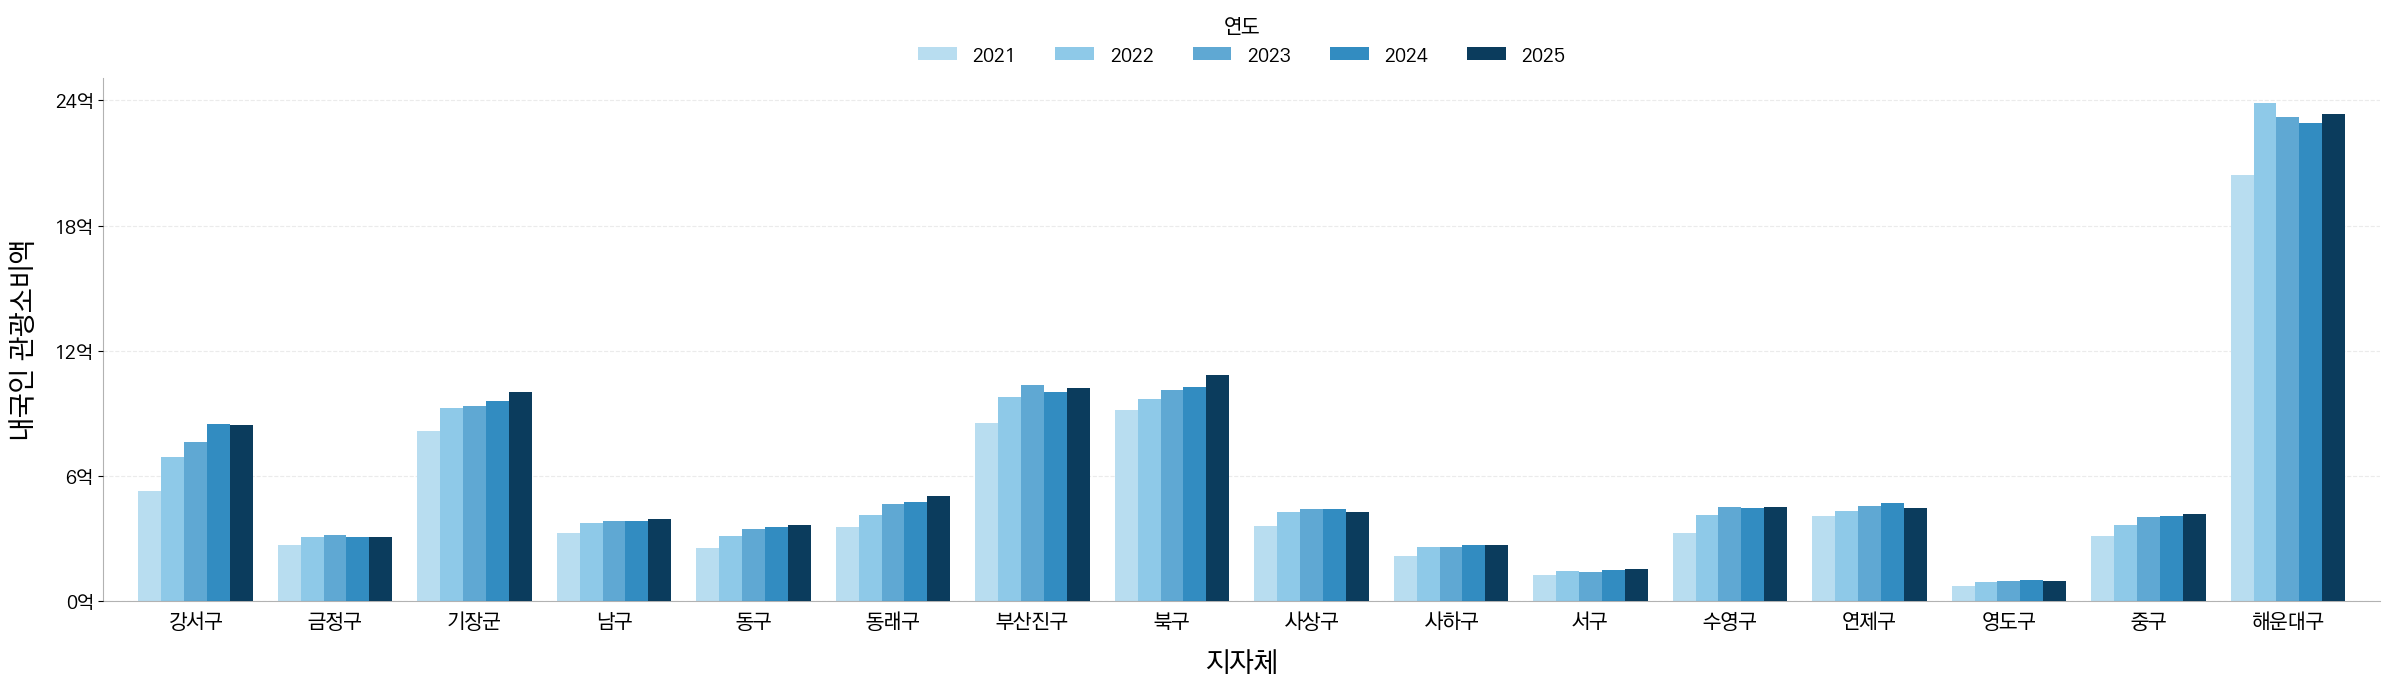

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator

df2 = df.copy()

# 데이터 정렬
plot_df = (
    df2
    .sort_values(['지자체', '기준년월'])
    .copy()
)

# 피벗
pivot_domestic = plot_df.pivot(
    index='지자체',
    columns='기준년월',
    values='내국인'
)

# 가나다순 + 연도순
pivot_domestic = (
    pivot_domestic
    .sort_index()
    .reindex(columns=[2021, 2022, 2023, 2024, 2025])
)

# 파란 계열
colors = [
    '#B8DDF0',
    '#8EC9E8',
    '#5FA8D3',
    '#328CC1',
    '#0B3C5D'
]

# 가로로 긴 그래프
fig, ax = plt.subplots(figsize=(24, 7))

pivot_domestic.plot(
    kind='bar',
    ax=ax,
    color=colors,
    width=0.82,
    edgecolor='none'
)

# 축 설정
ax.set_xlabel(
    '지자체',
    fontsize=20,
    fontweight='bold',
    labelpad=12
)

ax.set_ylabel(
    '내국인 관광소비액',
    fontsize=20,
    fontweight='bold',
    labelpad=12
)

# 틱
ax.tick_params(
    axis='x',
    labelsize=15,
    rotation=0,
    pad=8,
    length=0
)

ax.tick_params(
    axis='y',
    labelsize=14
)

# 억 단위
ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, _: f'{x / 100_000_000:,.0f}억'
    )
)

# y축 틱 개수
ax.yaxis.set_major_locator(
    MaxNLocator(nbins=5)
)

# 범례 위쪽 중앙
ax.legend(
    title='연도',
    fontsize=14,
    title_fontsize=15,
    ncol=5,
    frameon=False,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    columnspacing=2
)

# 가로 보조선
ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.8,
    alpha=0.25
)

ax.set_axisbelow(True)

# 테두리 정리
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_alpha(0.3)
ax.spines['bottom'].set_alpha(0.3)

plt.tight_layout()

plt.savefig(
    '지자체별_연도별_내국인_관광소비액.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

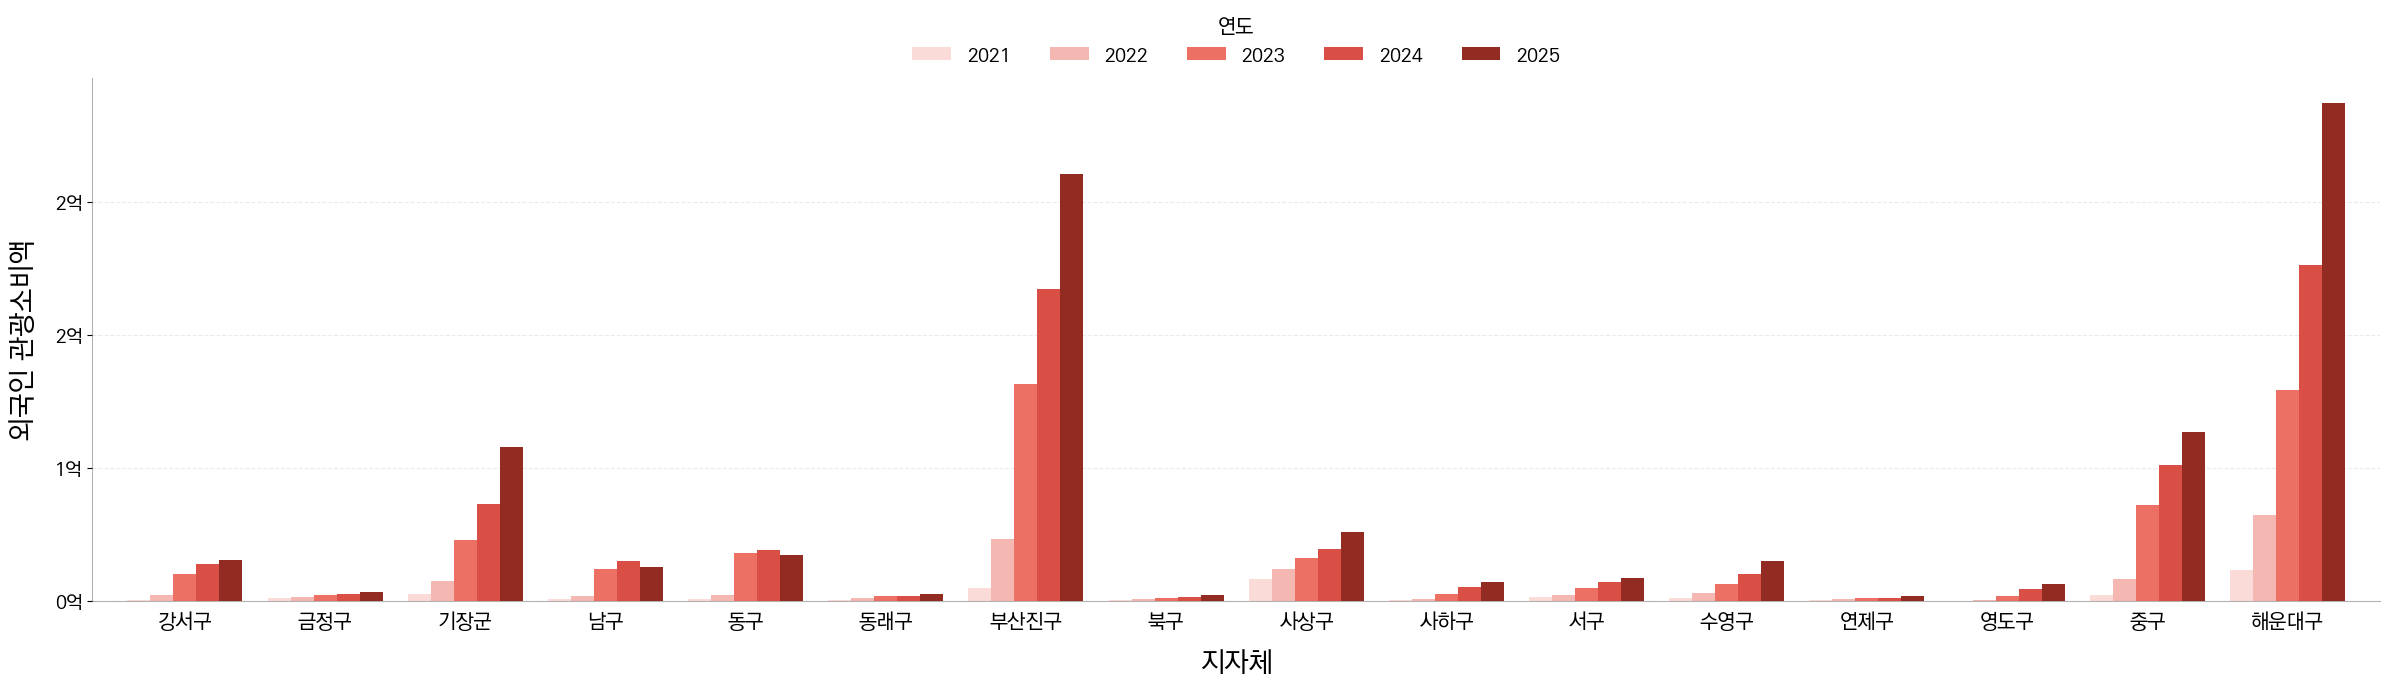

In [10]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator

df2 = df.copy()

# 데이터 정렬
plot_df = (
    df2
    .sort_values(['지자체', '기준년월'])
    .copy()
)

# 피벗
pivot_foreign = plot_df.pivot(
    index='지자체',
    columns='기준년월',
    values='외국인'
)

# 가나다순 + 연도순
pivot_foreign = (
    pivot_foreign
    .sort_index()
    .reindex(columns=[2021, 2022, 2023, 2024, 2025])
)

# 붉은 계열
colors = [
    '#FADBD8',
    '#F5B7B1',
    '#EC7063',
    '#D94F45',
    '#922B21'
]

# 가로로 긴 그래프
fig, ax = plt.subplots(figsize=(24, 7))

pivot_foreign.plot(
    kind='bar',
    ax=ax,
    color=colors,
    width=0.82,
    edgecolor='none'
)

# 축 설정
ax.set_xlabel(
    '지자체',
    fontsize=20,
    fontweight='bold',
    labelpad=12
)

ax.set_ylabel(
    '외국인 관광소비액',
    fontsize=20,
    fontweight='bold',
    labelpad=12
)

# 틱 설정
ax.tick_params(
    axis='x',
    labelsize=15,
    rotation=0,
    pad=8,
    length=0
)

ax.tick_params(
    axis='y',
    labelsize=14
)

# 억 단위
ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, _: f'{x / 100_000_000:,.0f}억'
    )
)

# y축 틱 개수
ax.yaxis.set_major_locator(
    MaxNLocator(nbins=5)
)

# 범례
ax.legend(
    title='연도',
    fontsize=14,
    title_fontsize=15,
    ncol=5,
    frameon=False,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    columnspacing=2
)

# 보조선
ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.8,
    alpha=0.25
)

ax.set_axisbelow(True)

# 테두리 정리
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_alpha(0.3)
ax.spines['bottom'].set_alpha(0.3)

plt.tight_layout()

# 저장
plt.savefig(
    '지자체별_연도별_외국인_관광소비액.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()